len(data)=2059
Most common lengths: [(7, 754), (8, 561), (6, 416), (9, 235), (10, 93)]


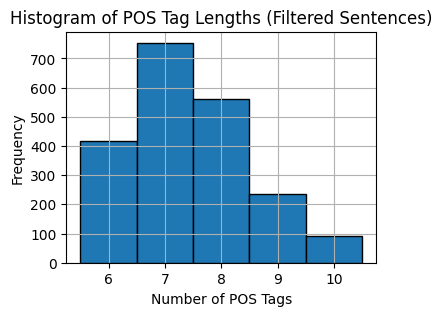

In [1]:
import matplotlib.pyplot as plt
from collections import Counter

path0 = './'
filename = 'syntax_mismatched_sentences.txt'
threshold = .44 #.42
n_lines = 2100  # Maximum number of valid lines to process

data = []
lengths = []
processed = 0  # Counter for valid lines

with open(f"{path0}{filename}", "r") as f:
    for line in f:
        if processed >= n_lines:
            break
        parts = line.strip().split('\t')
        if len(parts) == 5:
            sentence1, sentence2, tags1, tags2, word_overlap = parts
            try:
                if (
                    float(word_overlap) < threshold and
                    len(tags1.split()) == len(tags2.split())
                ):
                    length = len(tags1.split())
                    lengths.append(length)
                    data.append((sentence1, sentence2, tags1, tags2, word_overlap))
                    processed += 1
            except ValueError:
                continue

# Count frequencies of lengths
length_counts = Counter(lengths)

print(f'{len(data)=}')

# Print most common lengths
print("Most common lengths:", length_counts.most_common(10))

# Plot histogram
plt.figure(figsize=(4, 3))
plt.hist(lengths, bins=range(min(lengths), max(lengths) + 2), edgecolor='black', align='left')
plt.title("Histogram of POS Tag Lengths (Filtered Sentences)")
plt.xlabel("Number of POS Tags")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [2]:
with open(f"{path0}sentences0.txt", "w") as f1, \
    open(f"{path0}sentences1.txt", "w") as f2:
    for s1, s2, tags1,tags2, word_overlap in data:
        f1.write(s1 + "\n")
        f2.write(s2 + "\n")

In [3]:
# Map each unique length to a unique group ID
unique_lengths = sorted(set(lengths))
length_to_group_id = {length: idx for idx, length in enumerate(unique_lengths)}

# Generate group IDs for each line in the filtered data
group_ids = [length_to_group_id[length] for length in lengths]

# Save group IDs to file
with open("group_ids.txt", "w") as out_f:
    for gid in group_ids:
        out_f.write(f"{gid}\n")


In [4]:
matched_file = '/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/syntax_matched_sentences.txt'

# Collect all sentences from the first and second columns of the matched file
matched_sentences = set()
with open(matched_file, "r") as f:
  for line in f:
    parts = line.strip().split('\t')
    if len(parts) >= 2:
      matched_sentences.add(parts[0])
      matched_sentences.add(parts[1])

# Check how many sentences from syntax_mismatched_sentences.txt are present in matched_sentences
present_count = 0
for s1, s2, _, _, _ in data:
  if s1 in matched_sentences or s2 in matched_sentences:
    present_count += 1

print(f"Number of sentences from syntax_mismatched_sentences.txt present in either column of matched file: {present_count}")

Number of sentences from syntax_mismatched_sentences.txt present in either column of matched file: 2058


In [5]:
from collections import Counter

# For each pair in data, check if s1 or s2 is present in matched_sentences and record which column matches
match_results = []
for s1, s2, _, _, _ in data:
  if s1 in matched_sentences:
    match_results.append('first')
  elif s2 in matched_sentences:
    match_results.append('second')
  else:
    print(s1,s2)
    match_results.append('none')

# Count occurrences of each match type
match_type_counts = Counter(match_results)
print("Match type counts:", match_type_counts)

The chef prepared the dish carefully to impress the diners The manager gave the instruction clearly to begin the work
Match type counts: Counter({'first': 2028, 'second': 30, 'none': 1})
